# WP I2 — Bootstrap CI + Welch t-test (Fig 4)
**Author:** Yesunkh · **Question:** Is the warming between the early and the recent period *real*, or could it be sampling chance?

Two periods of the German annual-mean series:
- **Early:** 1881–1950 (n = 70)
- **Recent:** 1990–2025 (n = 36)

Main result = a **bootstrap 95% CI** for the difference in means; cross-checked with a **Welch t-test** + **Cohen's d**.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("../data/clean/temp_annual_regions.csv")
de = df[["jahr", "Deutschland"]].copy()   # national annual mean
de.head(3)

,jahr,Deutschland
0,1881,7.31
1,1882,8.34
2,1883,7.88


## 1. Define the two periods
Long early baseline (1881–1950) vs. recent period (1990–2025). Both have n ≥ 30, so the sample means are well-behaved (CLT, VL5). Multi-decade blocks instead of single years on purpose: single years are *weather*, blocks are *climate*.

In [2]:
a = de.loc[de["jahr"].between(1881, 1950), "Deutschland"].to_numpy()  # early,  n=70
b = de.loc[de["jahr"].between(1990, 2025), "Deutschland"].to_numpy()  # recent, n=36

print(f"n_a = {a.size}, n_b = {b.size}")
print(f"mean early  = {a.mean():.2f} °C")
print(f"mean recent = {b.mean():.2f} °C")
print(f"observed difference = {b.mean()-a.mean():.2f} °C")

n_a = 70, n_b = 36
mean early  = 8.05 °C
mean recent = 9.44 °C
observed difference = 1.39 °C


## 2. Bootstrap 95% CI — the main result
**Idea:** we don't know the true distribution of the difference in means, so we *resample* the data we have. Draw n values **with replacement** from each period, recompute the difference, repeat 10,000×. The middle 95% of those differences is the confidence interval — no normality assumption needed.

**Reslt/ Interpretation:** if 0 is *not* inside the interval, the difference is not explainable by sampling chance. The fixed seed makes it reproducible.

In [3]:
rng = np.random.default_rng(42)   #original seed was set to 42, values infered happened using 42 as seed, 
boot = np.array([
    rng.choice(b, size=b.size, replace=True).mean()
    - rng.choice(a, size=a.size, replace=True).mean()
    for _ in range(10_000)
])
ci = np.percentile(boot, [2.5, 97.5])
print(f"deltamean = {b.mean()-a.mean():.2f} °C, bootstrap 95% CI [{ci[0]:.2f}, {ci[1]:.2f}]")

deltamean = 1.39 °C, bootstrap 95% CI [1.10, 1.67]


## 3. Cross-check: Welch t-test + Cohen's d
A second, independent method. **Welch** (not Student) because we do not assume equal variances. **Cohen's d** standardizes the gap (how many pooled SDs apart the periods are).

In [4]:
t, p = stats.ttest_ind(b, a, equal_var=False)   # Welch: no equal-variance assumption
d = (b.mean() - a.mean()) / np.sqrt((a.std(ddof=1)**2 + b.std(ddof=1)**2) / 2)
print(f"Welch t = {t:.2f}, p = {p:.2e}, Cohen's d = {d:.2f}")

Welch t = 9.28, p = 4.23e-13, Cohen's d = 1.97


## 4. Fig 4 — distributions of the two periods

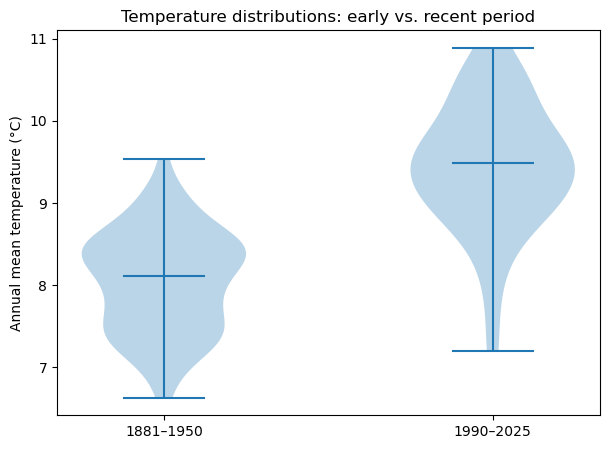

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.violinplot([a, b], showmedians=True)
ax.set_xticks([1, 2])
ax.set_xticklabels(["1881–1950", "1990–2025"])
ax.set_ylabel("Annual mean temperature (°C)")
ax.set_title("Temperature distributions: early vs. recent period")
fig.savefig("../figures/fig4_periods.png", dpi=200, bbox_inches="tight")
plt.show()

## Takeaway
The recent period (1990–2025) is **+1.39 °C** warmer than 1881–1950. The bootstrap 95% CI **[1.10, 1.67] excludes 0**, and the Welch test agrees (t = 9.28, p ≈ 4e-13, Cohen's d = 1.97 → "huge" effect). **Both methods agree: the difference is real, not sampling chance.**

*Limitation:* annual values are autocorrelated, so the effective sample size is smaller than n — the bootstrap CI is therefore slightly optimistic (narrow), but nowhere near enough to pull 0 into the interval.